In [2]:
import os

from lightning import pytorch as pl
import torch
import numpy as np
import pandas as pd
from pathlib import Path

import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from chemprop import data, featurizers, models, nn
from chemprop.nn import metrics
from chemprop.models import multi

In [193]:
input_path = "data/processed/all_optical_data_including_duplicates.csv"
smiles_columns = ['smiles', 'solvent']
target_columns = ['emi_lifetime(ns)']

df_input = pd.read_csv(input_path, usecols=['smiles', 'solvent', 'emi_lifetime(ns)'])
df_input.dropna(inplace=True)
smiss = df_input.loc[:, smiles_columns].values
ys = df_input.loc[:, target_columns].values

datapoints = [[data.MoleculeDatapoint.from_smi(smis[0], y) for smis, y in zip(smiss, ys)]]
datapoints += [[data.MoleculeDatapoint.from_smi(smis[i]) for smis in smiss] for i in range(1, len(smiles_columns))]

In [194]:
df_input

,smiles,solvent,emi_lifetime(ns)
12410,N#Cc1cc2ccc(O)cc2oc1=O,O,2.804262
12411,N#Cc1cc2ccc([O-])cc2oc1=O,O,3.961965
12412,CCCCCCCCCCCC#CC#CCCCCCCCCCN1C(=O)c2ccc3c4ccc5c...,ClC(Cl)Cl,3.602954
12413,[O-]c1c(-c2nc3ccccc3s2)cc2ccc3cccc4ccc1c2c34,CC#N,3.810000
12414,[O-]c1c(-c2nc3ccccc3s2)cc2ccc3cccc4ccc1c2c34,CS(C)=O,4.700000
...,...,...,...
31610,c1cc2c3ccc[n+]4cccc(c5ccc[n+](c1)c25)c34,CC#N,7.400000
31611,c1cc2c3ccc[n+]4cccc(c5ccc[n+](c1)c25)c34,C[N+](=O)[O-],6.200000
31612,c1cc2c3ccc[n+]4cccc(c5ccc[n+](c1)c25)c34,CS(C)=O,4.400000
31616,c1cc2c3c(c1)-c1cccc4cccc(c14)B3c1cccc3cccc-2c13,Cc1ccccc1,6.310000


In [195]:
component_to_split_by = 0 # index of the component to use for structure based splits
mols = [d.mol for d in datapoints[component_to_split_by]]

train_indices, val_indices, test_indices = data.make_split_indices(mols, "scaffold_balanced", (0.8, 0.1, 0.1))
train_data, val_data, test_data = data.split_data_by_indices(
    datapoints, train_indices, val_indices, test_indices
)

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)
c:\Users\Elwuz\miniconda3\envs\chemprop-v2\Lib\site-packages\astartes\samplers\extrapolation\scaffold.py:48: NoMatchingScaffold: No matching scaffold was found for the 9 molecules corresponding to indices {295, 296, 297, 298, 299, 300, 301, 302, 303}
  warnings.warn(


In [196]:
#Display test set
test_indices = [idx for sublist in test_indices for idx in sublist]
df_test = df_input.iloc[test_indices].reset_index(drop=True)
df_test

,smiles,solvent,emi_lifetime(ns)
0,C(#Cc1cccs1)C(C#Cc1cccs1)=Cc1ccc(C=C(C#Cc2cccs...,ClC(Cl)Cl,1.60
1,O=Cc1ccc(C#CC(C#Cc2ccc(C=O)s2)=Cc2ccc(C=C(C#Cc...,ClC(Cl)Cl,0.80
2,C(#Cc1cccs1)C(C#Cc1cccs1)=Cc1ccc(C=C(C#Cc2cccs...,ClC(Cl)Cl,1.60
3,COCCOCCOCCOCC(COCCOCCOCCOC)Oc1cc(/C=C/c2ccc(C=...,ClCCl,0.90
4,CCCCCCOc1cc(/C=C/c2cc(OCCCCCC)c(/C=C/c3cc(OCCC...,ClCCl,1.22
...,...,...,...
676,C(=C/c1ccc(/C=C/c2c3ccccc3cc3ccccc23)cc1)\c1cc...,C1CCOC1,2.03
677,C(#Cc1cccs1)C(C#Cc1cccs1)=Cc1ccc(C=C(C#Cc2cccs...,ClC(Cl)Cl,0.70
678,O=Cc1ccc(C#CC(C#Cc2ccc(C=O)s2)=Cc2ccc(C=C(C#Cc...,ClC(Cl)Cl,0.50
679,C(#Cc1cccs1)C(C#Cc1cccs1)=Cc1ccc(C=C(C#Cc2cccs...,ClC(Cl)Cl,0.70


In [ ]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

train_dset = [data.MoleculeDataset(train_data[0][i], featurizer) for i in range(len(smiles_columns))]
val_dset = [data.MoleculeDataset(val_data[0][i], featurizer) for i in range(len(smiles_columns))]
test_dset = [data.MoleculeDataset(test_data[0][i], featurizer) for i in range(len(smiles_columns))]

train_mcdset = data.MulticomponentDataset(train_dset)
scaler = train_mcdset.normalize_targets()
val_mcdset = data.MulticomponentDataset(val_dset)
val_mcdset.normalize_targets(scaler)
test_mcdset = data.MulticomponentDataset(test_dset)

BATCH_SIZE = 64
num_workers = 8 # number of workers for dataloader. 0 means using main process for data loading
train_loader = data.build_dataloader(train_mcdset, batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=True, persistent_workers=True)
val_loader = data.build_dataloader(val_mcdset, batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=True, persistent_workers=True, shuffle=False)
test_loader = data.build_dataloader(test_mcdset, batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=True, persistent_workers=True, shuffle=False)

In [198]:
torch.manual_seed(0) #use same random seed every time
np.random.seed(0)

mcmp = nn.MulticomponentMessagePassing(
    blocks=[nn.BondMessagePassing() for _ in range(len(smiles_columns))],
    n_components=len(smiles_columns),
)

agg = nn.MeanAggregation()

In [199]:
#multicomponent code, could add dropout in the FFN (e.g., dropout=0.2–0.5)
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)

ffn = nn.RegressionFFN(
    n_tasks = len(target_columns),
    input_dim=mcmp.output_dim,
    output_transform=output_transform,
)

metric_list = [metrics.RMSE(), metrics.MAE()] # Only the first metric is used for training and early stopping

In [200]:
#multicomponent code
mcmpnn = multi.MulticomponentMPNN(
    mcmp,
    agg,
    ffn,
    metrics=metric_list,
)

mcmpnn

MulticomponentMPNN(
  (message_passing): MulticomponentMessagePassing(
    (blocks): ModuleList(
      (0-1): 2 x BondMessagePassing(
        (W_i): Linear(in_features=86, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=372, out_features=300, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (tau): ReLU()
        (V_d_transform): Identity()
        (graph_transform): Identity()
      )
    )
  )
  (agg): MeanAggregation()
  (bn): Identity()
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=600, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0]])
    (output_transform): UnscaleTransform()
  )
  (X_d_transform): Identity()
  (metrics): ModuleList(


In [201]:
#code for training a model which will be saved
checkpoint = pl.callbacks.ModelCheckpoint(
    dirpath="checkpoints/",
    monitor="val_loss",
    save_top_k=1,
    mode="min",
    filename="all_data_emi_lifetime(ns)"
)

early_stop = pl.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    mode="min"
)

from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = torch.optim.AdamW(mcmpnn.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

In [202]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

Torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU count: 1


In [203]:
#multicomponent code
trainer = pl.Trainer(
    accelerator="gpu",
    logger=True,
    callbacks=[checkpoint, early_stop],
    max_epochs=300,
    deterministic=True
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [204]:
#multicomponent code
trainer.fit(mcmpnn, train_loader, val_loader)

c:\Users\Elwuz\miniconda3\envs\chemprop-v2\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\Elwuz\OneDrive\Documents\GitHub\Code Projects\uvvisml\uvvisml\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\Elwuz\miniconda3\envs\chemprop-v2\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (43) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ MulticomponentMessagePassing │  455 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation              │      0 │ train │     0 │
│ 2 │ bn              │ Identity                     │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN                │  180 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity                     │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList                   │      0 │ train │     0 │
└───┴─────────────────┴──────────────────────────────┴────────┴───────┴───────┘

Trainable params: 636 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 636 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\Elwuz\miniconda3\envs\chemprop-v2\Lib\site-packages\lightning\pytorch\core\saving.py:365: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


In [205]:
results = trainer.test(mcmpnn, test_loader, weights_only=False)  # weights_only=False is only required with pytorch lightning version 2.6.0 or newer

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │     3.47953200340271      │
│         test/rmse         │     7.358541965484619     │
└───────────────────────────┴───────────────────────────┘

In [206]:
#Show where model is saved
best_model_path = checkpoint.best_model_path
print(f"Best model saved at: {best_model_path}")

Best model saved at: C:\Users\Elwuz\OneDrive\Documents\GitHub\Code Projects\uvvisml\uvvisml\checkpoints\all_data_emi_lifetime(ns).ckpt


In [207]:
#Code for loading different model than the one just trained
#path = chemprop_dir / "examples" / "CIE_model_nm.ckpt"
#mcmpnn = models.multi.MulticomponentMPNN.load_from_checkpoint(path, map_location="cpu", weights_only=False)

In [208]:
#Predict and show results compared to known data
preds = trainer.predict(mcmpnn, test_loader) #Works with mcmpnn or chemprop_model
preds_tensor = torch.cat(preds, dim=0)

preds_array = preds_tensor.detach().cpu().numpy()

columns = ['emi_lifetime(ns)_pred']
df_test[columns] = preds_array

df_test

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,smiles,solvent,emi_lifetime(ns),emi_lifetime(ns)_pred
0,C(#Cc1cccs1)C(C#Cc1cccs1)=Cc1ccc(C=C(C#Cc2cccs...,ClC(Cl)Cl,1.60,4.020158
1,O=Cc1ccc(C#CC(C#Cc2ccc(C=O)s2)=Cc2ccc(C=C(C#Cc...,ClC(Cl)Cl,0.80,3.923827
2,C(#Cc1cccs1)C(C#Cc1cccs1)=Cc1ccc(C=C(C#Cc2cccs...,ClC(Cl)Cl,1.60,4.020158
3,COCCOCCOCCOCC(COCCOCCOCCOC)Oc1cc(/C=C/c2ccc(C=...,ClCCl,0.90,5.130110
4,CCCCCCOc1cc(/C=C/c2cc(OCCCCCC)c(/C=C/c3cc(OCCC...,ClCCl,1.22,4.764414
...,...,...,...,...
676,C(=C/c1ccc(/C=C/c2c3ccccc3cc3ccccc23)cc1)\c1cc...,C1CCOC1,2.03,5.277188
677,C(#Cc1cccs1)C(C#Cc1cccs1)=Cc1ccc(C=C(C#Cc2cccs...,ClC(Cl)Cl,0.70,3.770777
678,O=Cc1ccc(C#CC(C#Cc2ccc(C=O)s2)=Cc2ccc(C=C(C#Cc...,ClC(Cl)Cl,0.50,3.716638
679,C(#Cc1cccs1)C(C#Cc1cccs1)=Cc1ccc(C=C(C#Cc2cccs...,ClC(Cl)Cl,0.70,3.770777


In [209]:
def plot_and_save(true_values=str, preds=str, model=str, value_type=str, save_path=str):

  '''
  true_values: name of column containing experimental x or y values
  preds: name of column containing predicted x or y values
  model: name of model used to make prediction
  save_path: path where figure will be saved

  plots a parity plot and saves the figure to the specified path
  '''

  true_ys = df_test[true_values].tolist()
  preds_y = df_test[preds].tolist()

  fig = plt.figure(figsize=(8,5))
  plt.scatter(true_ys, preds_y, color='red', marker='o', label='Parity Plot')
  ax = plt.gca()
  lims = ax.get_xlim()
  ax.plot(lims, lims, color='black')
  plt.legend()
  plt.xlabel('Experimental')
  plt.ylabel('Predicted')
  title = 'Parity Plot of ' + model + ' ' + value_type + ' Values'
  plt.title(title)
  plt.grid(True)

  with open(save_path, "wb") as f:
      pickle.dump(fig, f)

  plt.show()

  print('Plot saved as: ' + save_path)

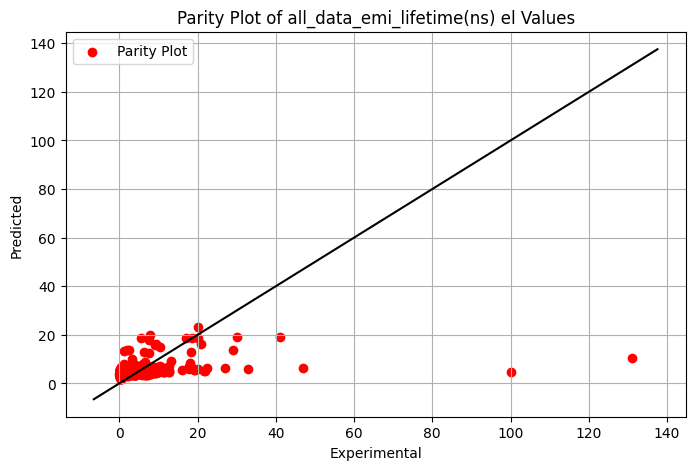

Plot saved as: emi_lifetime(ns)_Parity_emi_lifetime(ns)_model.pkl


In [ ]:
plot_and_save('emi_lifetime(ns)', 'emi_lifetime(ns)_pred', 'all_data_emi_lifetime(ns)', 'el', 'emi_lifetime(ns)_Parity_emi_lifetime(ns)_model-v1.pkl')

In [211]:
plot_and_save('emission_max', 'emi_max_pred', 'all_data_abs_emi_max_and_FWHM(nm)', 'emi', 'Abs_Parity_abs_emi_max_and_FWHM(nm)_model.pkl')

KeyError: 'emission_max'

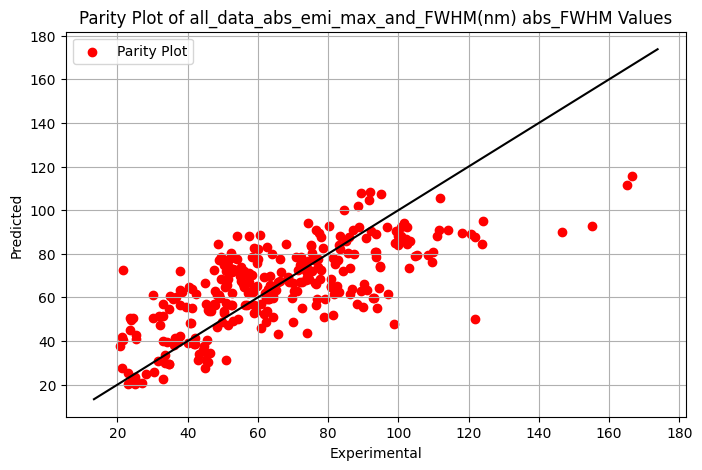

Plot saved as: Abs_Parity_abs_emi_max_and_FWHM(nm)_model.pkl


In [ ]:
plot_and_save('abs FWHM (nm)', 'abs_FWHM_pred', 'all_data_abs_emi_max_and_FWHM(nm)', 'abs_FWHM', 'Abs_Parity_abs_emi_max_and_FWHM(nm)_model.pkl')

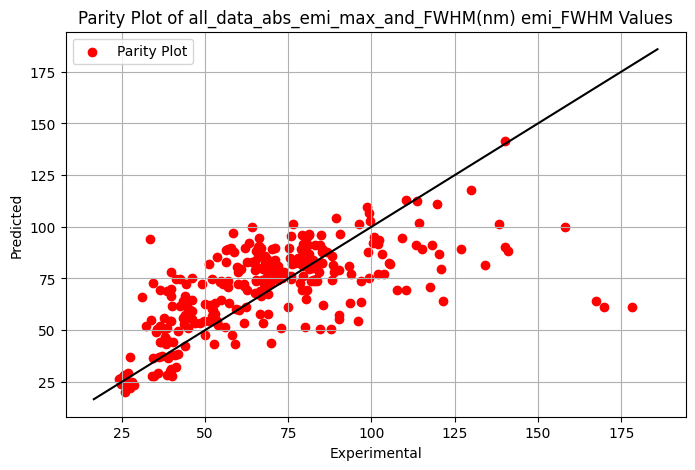

Plot saved as: Abs_Parity_abs_emi_max_and_FWHM(nm)_model.pkl


In [ ]:
plot_and_save('emi FWHM (nm)', 'emi_FWHM_pred', 'all_data_abs_emi_max_and_FWHM(nm)', 'emi_FWHM', 'Abs_Parity_abs_emi_max_and_FWHM(nm)_model.pkl')